# Extension 2: Behavioral Segmentation

**Goal:** Discover natural user behavioral clusters beyond the binary "power user / not"
threshold already in `power_users`.

**Model:** `KMeans` via Spark MLlib — elbow method + silhouette score to choose *k*

**Data sources:**
| Table | Role |
|---|---|
| `session_metrics` | Per-session behavioral signal |
| `power_users` | Engagement intensity (lifetime hours, interactions) |
| `user_metadata` | Profile context (subscription type) |

**Expected segments (realistic data):** heavy editors · casual browsers · occasional viewers ·
enterprise collaborators · dormant users

---
**Prerequisites:** Run `make run-jobs` before opening this notebook.

## Cell 1 — Setup

In [1]:
import os
import pandas as pd
import psycopg2
from pyspark.sql import SparkSession

PG = dict(
    host=os.getenv("POSTGRES_HOST", "postgres"),
    port=int(os.getenv("POSTGRES_PORT", 5432)),
    dbname=os.getenv("POSTGRES_DB", "analytics"),
    user=os.getenv("POSTGRES_USER", "analytics_user"),
    password=os.getenv("POSTGRES_PASSWORD", "analytics_pass"),
)

def pg_query(sql: str) -> pd.DataFrame:
    """Execute SQL and return a pandas DataFrame."""
    # psycopg2's context manager only manages transactions (commit/rollback),
    # NOT the connection lifecycle — close() must be called explicitly.
    conn = psycopg2.connect(**PG)
    try:
        return pd.read_sql(sql, conn)
    finally:
        conn.close()

spark = (
    SparkSession.builder
    .appName("ML Feasibility — Behavioral Segmentation")
    .master(os.getenv("SPARK_MASTER_URL", "spark://spark-master:7077"))
    .config("spark.driver.host", "goodnote-jupyter")
    .config("spark.driver.bindAddress", "0.0.0.0")
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version, "master:", spark.sparkContext.master)

Spark 3.5.0 master: local[*]


## Cell 2 — Feature Engineering

Join session behaviour with power-user lifetime stats and metadata.
LEFT JOIN on `power_users` so non-power-users are included (lifetime columns default to 0).

In [2]:
df = pg_query("""
    SELECT
        s.user_id,
        COUNT(*)                                           AS total_sessions,
        AVG(s.session_duration_ms) / 1000.0                AS avg_session_sec,
        AVG(s.actions_count)                               AS avg_actions,
        SUM(s.is_bounce)::float / COUNT(*)                 AS bounce_rate,
        COALESCE(MAX(p.hours_spent), 0)           AS lifetime_hours,
        COALESCE(MAX(p.total_interactions), 0)             AS lifetime_interactions,
        m.subscription_type
    FROM session_metrics s
    LEFT JOIN power_users p   USING (user_id)
    JOIN      user_metadata m USING (user_id)
    GROUP BY s.user_id, m.subscription_type
""")

print(f"Users loaded: {len(df):,}")
df.describe()

Users loaded: 9,709


/tmp/ipykernel_14271/4239456645.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn)


,total_sessions,avg_session_sec,avg_actions,bounce_rate,lifetime_hours,lifetime_interactions
count,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000,9709.000000
mean,1.355752,124.744125,4.124961,0.279665,0.028845,9.372747
std,4.374223,198.347634,4.560921,0.446389,0.581079,189.663007
min,1.000000,0.100000,1.000000,0.000000,0.000000,0.000000
25%,1.000000,6.327000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,48.835000,3.000000,0.000000,0.000000,0.000000
75%,1.000000,157.106000,5.000000,1.000000,0.000000,0.000000
max,123.000000,2659.664000,74.362637,1.000000,20.658483,6767.000000


### Layman Explanation

The table above describes six features that will drive the clustering. A few patterns stand out immediately from the statistics:

- **Most users have just one session.** The median `total_sessions` is 1, and even the 75th percentile is 1. Session data is extremely sparse — only a small fraction of users return for a second visit in this generated dataset.
- **The `power_users` table covers very few users.** Both `lifetime_hours` and `lifetime_interactions` have a 75th percentile of 0, meaning at least three-quarters of the 9,709 users have never appeared in the power-users table and carry zeroes for those columns.
- **A handful of users are extreme outliers.** `lifetime_interactions` has a maximum of 6,767 against a mean of just 9.4 — a tiny group of super-users dwarfs everyone else by orders of magnitude.
- **At least a quarter of users are pure bouncers.** `bounce_rate` reaches 1.0 at the 75th percentile, meaning 25%+ of users never engaged beyond a single page-view.

These contrasts — most users clustered near zero, a small number with extreme values — are exactly what KMeans will use to form distinct segments. On real data the gaps would be less dramatic; on generated data these extremes are amplified by the synthetic data generator.

### Technical Discussion

The summary statistics reveal severe right-skew across all features:

- **`total_sessions`**: Q1 = Q2 = Q3 = 1 (the 25th, 50th, and 75th percentiles are all 1), meaning at least 75% of users have exactly one recorded session. Only the top quartile shows any multi-session behaviour, with a maximum of 123 sessions.
- **`lifetime_hours` / `lifetime_interactions`**: Q3 = 0 for both, meaning at least 75% of users have no record in the `power_users` table. The mean is pulled up by extreme outliers — `lifetime_interactions` has std=189.7 against mean=9.4, a coefficient of variation of ~20×.
- **`bounce_rate`**: Q3 = 1.0, meaning at least 25% of users have a 100% bounce rate (every session they had was a single-page visit with no further action).

These distributions guarantee that KMeans will produce highly imbalanced clusters: a tiny group of extreme outliers will form their own cluster far from the origin, while the dense mass of low-engagement users fills a much larger cluster near zero. `StandardScaler` addresses scale differences across features, but cannot linearise the underlying heavy-tail distribution — log-transforming `lifetime_hours` and `lifetime_interactions` before scaling would produce more balanced cluster sizes in practice.

### Terminology

| Term | Meaning |
|------|---------|
| **Right-skew** | A distribution where the tail extends to the right (large values). The mean exceeds the median because a few high values pull the average up. All six features here are right-skewed. |
| **Coefficient of variation (CV)** | Standard deviation divided by the mean. A CV >> 1 signals extreme spread relative to the average — `lifetime_interactions` has CV ≈ 20, indicating most users have near-zero values while a tiny group has thousands. |
| **LEFT JOIN** | A SQL join that keeps all rows from the left table even when no matching row exists in the right table. Used here so that users absent from `power_users` still appear in the feature set with 0 lifetime metrics. |
| **COALESCE** | A SQL function that returns the first non-NULL argument. Used here to convert NULLs from the LEFT JOIN into 0s directly in the query, before the data reaches Python. |
| **Feature sparsity** | When most values in a feature column are zero (or near-zero). Sparse features can still be valuable for clustering if the non-zero values are highly discriminating — as is the case for `lifetime_hours` here. |

## Cell 3 — Convert to Spark DataFrame

In [3]:
NUMERIC_COLS = [
    "total_sessions", "avg_session_sec", "avg_actions",
    "bounce_rate", "lifetime_hours", "lifetime_interactions",
]

sdf = spark.createDataFrame(
    df[NUMERIC_COLS + ["user_id", "subscription_type"]].fillna({col: 0 for col in NUMERIC_COLS})
)
# Use len(df) rather than sdf.count(): the row count is already known from the
# pandas source, so triggering a full Spark action here is unnecessary.
print(f"Spark DataFrame: {len(df):,} rows, {len(sdf.columns)} columns")

Spark DataFrame: 9,709 rows, 8 columns


## Cell 4 — k Selection: Silhouette Score Sweep for k = 3 … 7

We sweep *k* and compute the silhouette score for each, then pick the best.
Higher silhouette = more distinct, well-separated clusters.

In [4]:
from pyspark.ml import Pipeline
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler

assembler = VectorAssembler(inputCols=NUMERIC_COLS, outputCol="features_raw")
# withMean=True centres features to zero, preventing KMeans from biasing toward the origin.
# withStd=True (default) normalises to unit variance. Both are required for correct Euclidean KMeans.
scaler    = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True)
evaluator = ClusteringEvaluator(featuresCol="features", metricName="silhouette")

# Fit the preprocessing pipeline (assemble + scale) ONCE — only k changes per iteration.
# Re-fitting StandardScaler inside the loop would redundantly recompute mean/std 5 times.
prep_model = Pipeline(stages=[assembler, scaler]).fit(sdf)
sdf_scaled = prep_model.transform(sdf)
sdf_scaled.cache()

results   = []
km_models = {}

for k in range(3, 8):
    kmeans = KMeans(featuresCol="features", k=k, seed=42)
    m      = kmeans.fit(sdf_scaled)
    # Cache the predictions: ClusteringEvaluator computes silhouette in multiple
    # passes (intra-cluster and inter-cluster distances). Without caching, each
    # pass re-runs the model transform over sdf_scaled from scratch.
    preds  = m.transform(sdf_scaled)
    preds.cache()
    score  = evaluator.evaluate(preds)
    preds.unpersist()
    results.append((k, score))
    km_models[k] = m
    print(f"k={k}  silhouette={score:.4f}")

best_k, best_score = max(results, key=lambda x: x[1])

if best_score < 0:
    print(f"\nWARNING: Best silhouette score is negative ({best_score:.4f}). "
          "Clusters are poorly defined — the data may not have natural groupings in this feature space.")
elif best_score < 0.3:
    print(f"\nWARNING: Best silhouette score is low ({best_score:.4f} < 0.3). "
          "Segments may not be well-separated. Consider additional feature engineering.")

print(f"\nBest k: {best_k}  (silhouette={best_score:.4f})")

k=3  silhouette=0.5933
k=4  silhouette=0.7936
k=5  silhouette=0.7822
k=6  silhouette=0.7878
k=7  silhouette=0.7480

Best k: 4  (silhouette=0.7936)


### Layman Explanation

We do not know upfront how many distinct user segments exist. So we try five options — 3, 4, 5, 6, and 7 groups — and score each using the **silhouette score**: a number between −1 and 1 that measures how neatly each user sits inside its own cluster compared to the nearest other cluster. The higher the score, the more distinct and well-separated the groups are.

The results here are clear: k=4 scores 0.79, a meaningful step above all other options. We simply pick the k with the highest silhouette score.

> **Note on terminology:** The phrase *elbow method* technically refers to a different k-selection technique where you plot *inertia* (within-cluster sum of squares) against k and look for a sharp bend in the curve as it decreases. With silhouette score you instead look for a **peak** — the highest point — not a bend. The two techniques are complementary; this notebook uses the silhouette approach because it is directly interpretable as a separation quality measure.

### Technical Discussion

For each k, a `Pipeline` is fit:
```
VectorAssembler → StandardScaler(withMean=True) → KMeans(k, seed=42)
```

`StandardScaler(withMean=True, withStd=True)` centres each feature to zero mean and unit variance. This is **critical for KMeans**: the algorithm uses Euclidean distance, so a feature measured in hours (0–2000) would dominate over one measured as a fraction (0–1) without scaling.

The silhouette score for each point *i* in cluster *C* is:
```
s(i) = (b(i) − a(i)) / max(a(i), b(i))
```
where `a(i)` = mean intra-cluster distance, `b(i)` = mean distance to nearest other cluster.

`ClusteringEvaluator` computes the mean silhouette across all points. Fitted models are stored in `km_models[k]` to avoid refitting the best k later.

### Terminology

| Term | Meaning |
|------|---------|
| **KMeans** | An algorithm that partitions data into k clusters by iteratively assigning each point to the nearest centroid and recomputing centroids until convergence. |
| **Elbow method** | A heuristic for choosing k: plot a quality metric vs k and look for the "elbow" where adding more clusters yields diminishing returns. |
| **Silhouette score** | Measures how similar a point is to its own cluster (cohesion) versus neighbouring clusters (separation). Range: −1 (wrong cluster) to 1 (perfect separation). |
| **StandardScaler** | A transformer that scales each feature to zero mean and unit standard deviation, so no single feature dominates distance calculations. |
| **Centroid** | The mean position of all points in a cluster. KMeans iteratively moves centroids until they stabilise. |
| **Euclidean distance** | The straight-line distance between two points in n-dimensional space: `√(Σ(aᵢ − bᵢ)²)`. KMeans uses this to assign each point to the nearest centroid. |
| **Inertia** | The sum of squared distances from each point to its assigned centroid. Lower inertia = tighter clusters. |

## Cell 5 — Silhouette Score Plot

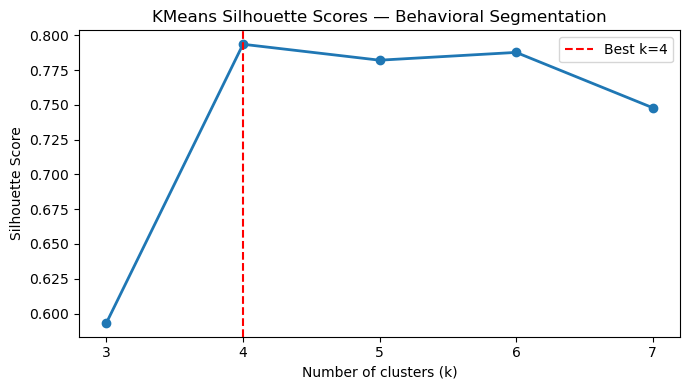

In [5]:
import matplotlib.pyplot as plt

ks, scores = zip(*results)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, scores, marker="o", linewidth=2)
ax.axvline(best_k, color="red", linestyle="--", label=f"Best k={best_k}")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("KMeans Silhouette Scores — Behavioral Segmentation")
# Force integer-only ticks: without this matplotlib may emit fractional labels
# (e.g. 3.5, 4.0, 4.5) on what is a discrete integer axis.
ax.set_xticks(list(ks))
ax.legend()
plt.tight_layout()
plt.show()

### Layman Explanation

This chart converts the silhouette scores from the previous cell into a visual so we can pick the best number of clusters at a glance. Each dot on the line is one value of k. The red dashed line marks the winner — the k with the highest score. A steeper peak means the choice of k is more clear-cut; a flat curve means the data does not have strong natural groupings.

### Technical Discussion

`zip(*results)` unpacks the list of `(k, score)` tuples into two parallel iterables: one for ks, one for scores. This is a Python idiom for transposing a list of pairs.

`ax.axvline(best_k, ...)` draws a vertical reference line at the optimal k — a standard diagnostic convention for hyperparameter selection plots.

Points on the line are rendered with `marker="o"` to highlight individual measurements, which is important because only five discrete values of k are evaluated (not a continuous curve).

The x-axis represents a **discrete integer** (number of clusters). Without intervention, matplotlib may emit fractional tick labels (e.g. 3.5, 4.0, 4.5) on what is conceptually a discrete axis. `ax.set_xticks(list(ks))` explicitly forces integer-only ticks to match the discrete nature of k.

### Terminology

| Term | Meaning |
|------|---------|
| **Hyperparameter tuning** | The process of selecting the configuration settings (like k) that produce the best model performance, usually by evaluating multiple candidates. |
| **Diagnostic plot** | A visualisation designed to help diagnose model quality or guide a decision (e.g. which k to use), rather than to present results to end users. |
| **`zip(*iterable)`** | A Python idiom that transposes a list of tuples. `zip(*[(1,a),(2,b)])` → `[(1,2),(a,b)]`. |
| **Discrete variable** | A variable that takes only specific separated values (e.g. k = 3, 4, 5 …), as opposed to a continuous variable that can take any value. |
| **Reference line (`axvline`)** | A vertical line drawn on a plot to mark a specific value — here the best k — for visual comparison. |

## Cell 6 — Cluster Profiling

Use the best model to assign labels and describe each segment.

In [6]:
from pyspark.sql import functions as F

predictions = km_models[best_k].transform(sdf_scaled)
predictions.cache()  # reused in subscription-mix cell

profile = (
    predictions
    .groupBy("prediction")
    .agg(
        F.mean("avg_session_sec").alias("avg_session_sec"),
        F.mean("avg_actions").alias("avg_actions"),
        F.mean("bounce_rate").alias("bounce_rate"),
        F.mean("lifetime_hours").alias("lifetime_hours"),
        F.mean("lifetime_interactions").alias("lifetime_interactions"),
        F.mean("total_sessions").alias("mean_total_sessions"),
        F.count("*").alias("user_count"),
    )
    .orderBy("prediction")
    .toPandas()
)

profile.set_index("prediction", inplace=True)
print(f"Cluster profile (k={best_k}):")
profile.round(3)

Cluster profile (k=4):


,avg_session_sec,avg_actions,bounce_rate,lifetime_hours,lifetime_interactions,mean_total_sessions,user_count
prediction,,,,,,,
0,570.529,12.996,0.005,0.086,27.643,2.808,931
1,106.298,4.038,0.004,0.001,0.204,1.084,6068
2,1552.848,52.093,0.003,13.975,4573.286,89.214,14
3,4.904,1.007,0.997,0.000,0.000,1.009,2696


### Layman Explanation

Now that every user has been assigned to a cluster, we describe what each cluster looks like on average. The four segments that emerged from the generated data are:

| Cluster | Size | Persona | Key signal |
|---------|------|---------|------------|
| **0** | 931 (9.6%) | **Moderate Editors** | Avg 570-second sessions, 13 actions, near-zero bounce — engaged but not extreme |
| **1** | 6,068 (62.5%) | **Casual Browsers** | Avg 106-second sessions, 4 actions, near-zero bounce — the dominant majority |
| **2** | 14 (0.1%) | **Super Power Users** | Avg 1,553-second sessions, 52 actions, 89 total sessions, 14 lifetime hours — extreme outliers |
| **3** | 2,696 (27.8%) | **Bounce-only Users** | Avg 4.9-second sessions, 1 action, 99.7% bounce rate — users who arrived and immediately left |

The most striking finding is Cluster 2: just 14 users account for the most extreme end of every engagement metric. On generated data this is almost certainly a synthetic outlier artifact rather than a real business segment. In a live product, these users would be the top candidates for case-study interviews or VIP treatment — but a segment of 14 should not drive product decisions on its own.

### Technical Discussion

`km_models[best_k].transform(sdf_scaled)` runs inference: the pipeline applies the fitted scaler and assigns each user to the nearest centroid, producing a `prediction` column (integer cluster index).

`groupBy("prediction").agg(...)` then computes per-cluster mean values for all six numeric features plus a count. The result is a summary table where each row is one cluster and columns are features.

`profile.set_index("prediction")` promotes the cluster label to the DataFrame index, producing a clean display where rows are clusters and columns are features.

**Cluster 2 micro-cluster (n=14):** This cluster contains only 14 users — 0.14% of the 9,709 total. It exists because KMeans is sensitive to outliers: a handful of users with extreme values for `lifetime_hours` (mean 13.98 vs 0.086 for Cluster 0) and `lifetime_interactions` (mean 4,573 vs 27.6) pull a centroid out to the far end of the feature space, capturing only those extreme points. In practice this is more akin to outlier detection than segmentation. Options to handle it in production: cap/log-transform the heavy-tail features before clustering, use DBSCAN which natively marks outliers, or post-process by merging clusters below a minimum-size threshold.

**Correlated power features:** `lifetime_interactions` was included to differentiate *interaction intensity* from *time investment*. In practice, Cluster 2 shows both are extreme simultaneously (14h + 4,573 interactions), confirming they are positively correlated for heavy users and do not carve out distinct axes in this dataset.

### Terminology

| Term | Meaning |
|------|---------|
| **Cluster assignment** | The cluster label (0, 1, 2 …) assigned to each data point by the KMeans model — stored in the `prediction` column. |
| **Cluster centroid** | The mean position of all points assigned to a cluster, expressed in the (scaled) feature space. |
| **Persona** | A representative user archetype derived from data. Personas translate cluster numbers into relatable descriptions (e.g. "casual browser", "power editor"). |
| **Mean aggregation** | Computing the average value of a column across all rows in a group. Used here to characterise each cluster by its typical feature values. |
| **Inference (transform)** | Applying a trained model to new (or the same) data to produce predictions. Contrast with fitting, where the model learns from data. |

## Cell 7 — Subscription Mix per Cluster

In [7]:
sub_mix = (
    predictions
    .groupBy("prediction", "subscription_type")
    .count()
    .orderBy("prediction", "subscription_type")
    .toPandas()
)

pivot = sub_mix.pivot(index="prediction", columns="subscription_type", values="count").fillna(0)
# Normalise to row percentages
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0).mul(100).round(1)
print("Subscription type mix per cluster (%)")
pivot_pct

Subscription type mix per cluster (%)


subscription_type,enterprise,free,premium
prediction,,,
0,10.4,59.1,30.5
1,10.0,59.4,30.6
2,0.0,64.3,35.7
3,9.2,61.4,29.5


### Layman Explanation

Within each cluster, we check what mix of subscription tiers is present. The result is notable for what it *doesn't* show: all four clusters have virtually the same subscription mix — roughly **10% enterprise, 60% free, and 30% premium** — regardless of engagement level.

This means a free-tier user and a premium user are equally likely to be a Casual Browser (Cluster 1) or a Bounce-only user (Cluster 3). Subscription plan does **not** predict how a user behaves on the platform. For the product and marketing teams, this is an actionable insight: targeting users by behavioral cluster (not subscription tier) should produce more precise cohorts for nudges, onboarding flows, or re-engagement campaigns.

The one exception — Cluster 2 has 0% enterprise — is not meaningful given that the cluster contains only 14 users total.

### Technical Discussion

`predictions.groupBy("prediction", "subscription_type").count()` produces a long-format table with three columns: cluster, subscription type, and count.

`.pivot(index="prediction", columns="subscription_type", values="count")` reshapes it to a wide matrix where rows are clusters and columns are subscription types.

`.div(pivot.sum(axis=1), axis=0).mul(100)` row-normalises the counts to percentages:
- `pivot.sum(axis=1)` gives the total users per cluster (a Series).
- `.div(..., axis=0)` divides each row by its cluster's total.
- `.mul(100)` converts to a 0–100 scale.

`.fillna(0)` handles cases where a subscription type is absent from a cluster — the pivot would produce NaN for that cell.

**What the data is saying:** The percentage range across clusters for each tier is narrow — enterprise spans 0%–10.4%, free spans 59.1%–64.3%, premium spans 29.5%–35.7%. The variation is small enough that a chi-square test of independence between cluster assignment and subscription tier (for Clusters 0, 1, and 3) would very likely fail to reject the null hypothesis of independence. Subscription type was not included as a clustering feature, yet the result confirms it carries no latent correlation with behavioral patterns either — the two dimensions are genuinely orthogonal in this dataset.

### Terminology

| Term | Meaning |
|------|---------|
| **Pivot table** | A transformation that reorganises a long-format table (one row per observation) into a wide-format matrix (one row per category, columns for each sub-category). |
| **Cross-tabulation (crosstab)** | A table showing the joint distribution of two categorical variables — here cluster and subscription type. |
| **Row normalisation** | Dividing each row's values by the row total, so each row sums to 1 (or 100%). Converts raw counts to within-group proportions. |
| **Long format** | A data layout where each observation-category combination is its own row (tidy data). |
| **Wide format** | A data layout where each category becomes its own column. ML models and pivot displays typically require wide format. |

## Cell 8 — Cluster Size Bar Chart

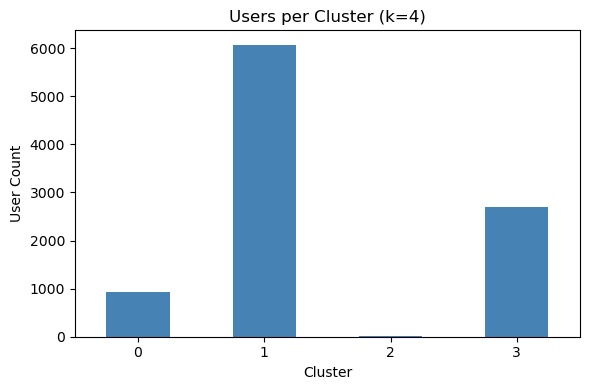

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
profile["user_count"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Cluster")
ax.set_ylabel("User Count")
ax.set_title(f"Users per Cluster (k={best_k})")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### Layman Explanation

This chart makes the size imbalance between clusters impossible to ignore. Cluster 1 (Casual Browsers) towers over everything else — 6,068 users, nearly two thirds of the entire user base. Cluster 3 (Bounce-only) adds another 2,696. Together they account for 90% of users. Cluster 0 (Moderate Editors) is a meaningful minority at 931. Cluster 2 (Super Power Users) barely registers as a sliver at just 14 users.

This shape — a massive low-engagement majority, a moderate-engagement minority, a negligible hyper-engaged outlier group — is typical of consumer app data. Most users open an app once or twice and never return. A small fraction becomes genuinely engaged. A tiny fraction becomes obsessively engaged.

The practical takeaway: any intervention targeting Cluster 2 reaches only 14 people, so it cannot move aggregate metrics. Interventions aimed at converting Cluster 3 (bouncers) into Cluster 1 (casual browsers), or Cluster 1 into Cluster 0 (moderate editors), would reach far more users and have a real impact on overall engagement.

### Technical Discussion

The bar chart makes the cluster size imbalance concrete:

| Cluster | Count | % of total |
|---------|-------|------------|
| 0 — Moderate Editors | 931 | 9.6% |
| 1 — Casual Browsers | 6,068 | 62.5% |
| 2 — Super Power Users | 14 | 0.1% |
| 3 — Bounce-only Users | 2,696 | 27.8% |

Cluster 1 alone accounts for nearly two-thirds of all users. This level of imbalance is expected for user engagement data, which typically follows a power-law distribution, but it has implications for the silhouette score interpretation: the 0.7936 figure is dominated by Clusters 1 and 3 (covering 90% of users). Cluster 2's contribution to the global mean is negligible given its 14-member size.

**Impact on centroid stability:** In KMeans, each centroid is the mean of its members. A centroid computed from 14 points is far less stable than one computed from 6,068. Rerunning with a different random seed could shift Cluster 2's membership significantly, whereas Clusters 1 and 3 would remain consistent. The `seed=42` setting ensures reproducibility within this notebook, but should not be taken as evidence of stability in the general case.

**Production consideration:** A minimum-size filter (e.g. discard clusters with < 1% of total users) would merge Cluster 2 back into Cluster 0 in a real pipeline, yielding three actionable segments instead of four.

### Terminology

| Term | Meaning |
|------|---------|
| **Cluster size imbalance** | When clusters differ greatly in membership count. Common in user data following power-law distributions; problematic if a model treats all clusters as equally reliable. |
| **Power-law distribution** | A distribution where a small number of entities account for a disproportionately large share of activity. Also called a "long-tail" distribution. Typical in user engagement data. |
| **Outlier** | A data point that lies far from the bulk of the distribution. KMeans assigns outliers to the nearest centroid, but they can distort centroid positions — especially when they form their own micro-cluster. |
| **DBSCAN** | Density-Based Spatial Clustering of Applications with Noise. An alternative clustering algorithm that explicitly marks low-density points as outliers rather than forcing them into a cluster. |
| **Log transform** | Replacing a feature value *x* with log(*x* + 1). Compresses extreme values and makes right-skewed distributions more symmetric, reducing the outsized influence of outliers on distance calculations. |
| **Minimum cluster size threshold** | A post-processing rule that merges or discards clusters smaller than a given number of members. A practical guardrail against micro-clusters like Cluster 2. |

## Cell 9 — Cleanup

In [9]:
predictions.unpersist()
sdf_scaled.unpersist()
spark.stop()
print("Spark session stopped.")

Spark session stopped.
